In [20]:
# If not installed, uncomment these lines and run once
# !pip install qiskit
# !pip install --upgrade qiskit qiskit-aer pylatexenc --quiet

In [21]:
# STEP 1: Import required libraries
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
from collections import Counter

In [11]:
# STEP 2: Define parameters
num_qubits = 16       # Total number of qubits (each will produce 1 random bit)
num_shots = 1024      # Number of times circuit will be run (sampling size)

In [23]:
# Create a quantum circuit with 16 qubits and 16 classical bits
qc = QuantumCircuit(num_qubits, num_qubits)

# STEP 3: Apply Hadamard gate to all qubits to create superposition
# Each qubit now represents both 0 and 1 simultaneously
for i in range(num_qubits):
    qc.h(i)

# STEP 4: Measure all qubits (collapsing superposition to 0 or 1)
qc.measure(range(num_qubits), range(num_qubits))

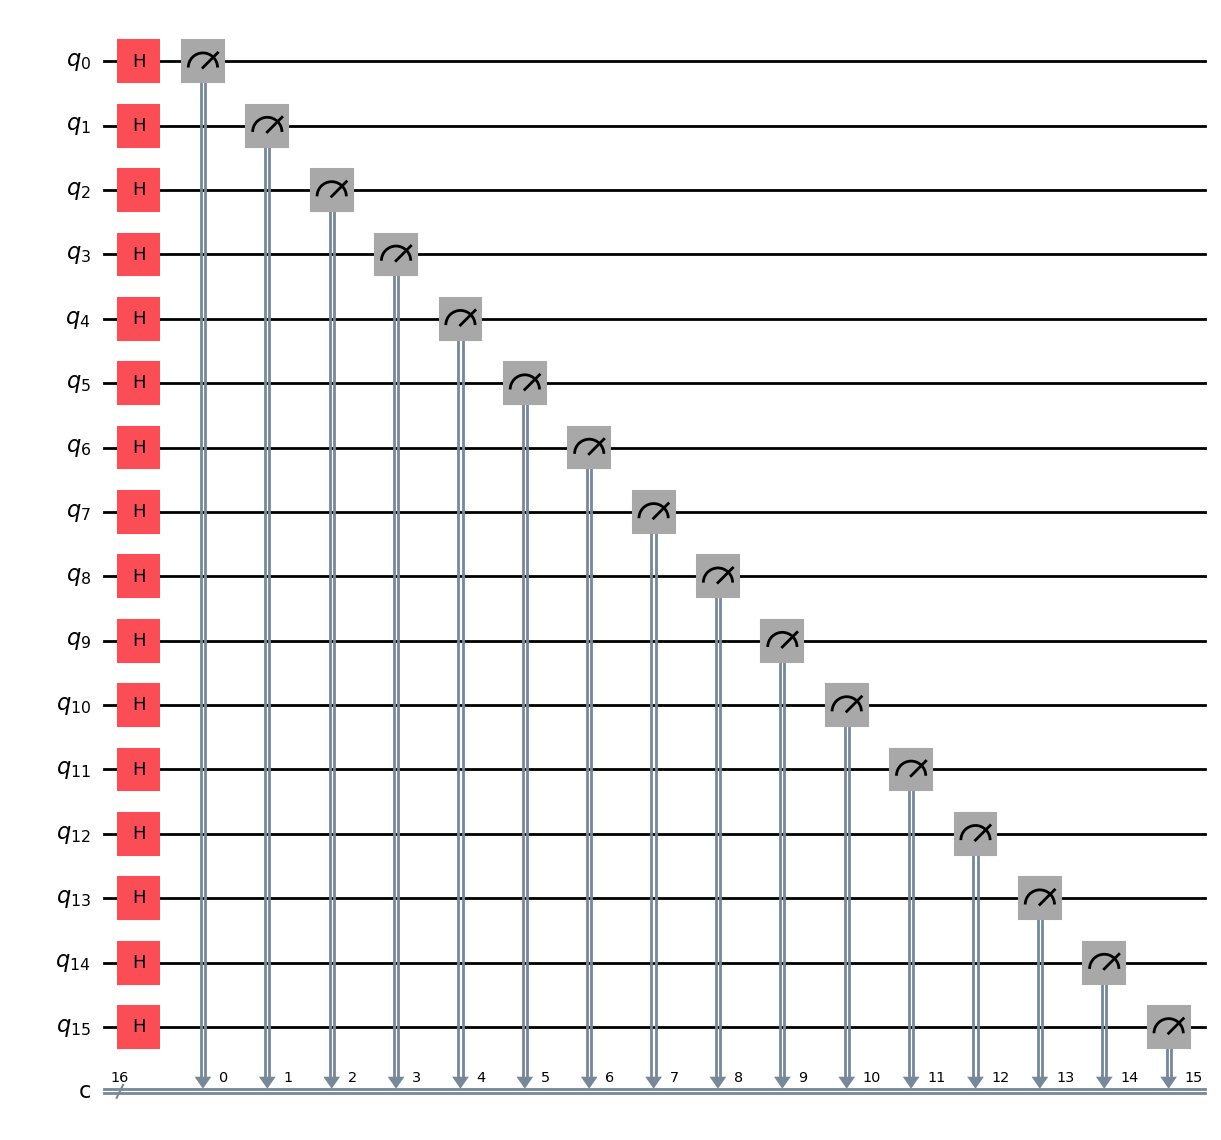

In [24]:
# STEP 5: Visualize the circuit
display(qc.draw(output='mpl', fold=-1))   # fold=-1 shows the full circuit without line breaks

In [15]:
simulator = Aer.get_backend('qasm_simulator')
t_qc = transpile(qc, simulator)
job = simulator.run(t_qc, shots=num_shots)
result = job.result()
counts = result.get_counts()

In [28]:
# STEP 6: Simulate the quantum circuit using QASM Simulator
simulator = Aer.get_backend('qasm_simulator')
t_qc = transpile(qc, simulator)
job = simulator.run(t_qc, shots=num_shots)
result = job.result()
counts = result.get_counts()   # Dictionary of measured results {‘0101...’: count}

# Convert to a sorted list of most common bitstrings
top_counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True))

# STEP 7: Display a few random numbers
print("🎲 Sample Random 16-bit Numbers Generated:")
for i, rn in enumerate(list(top_counts.keys())[:15], 1):
    print(f"{i}. {rn}  --> Decimal: {int(rn, 2)}")

🎲 Sample Random 16-bit Numbers Generated:
1. 1000011010111110  --> Decimal: 34494
2. 0001110001000010  --> Decimal: 7234
3. 1000101101110011  --> Decimal: 35699
4. 1010100000000111  --> Decimal: 43015
5. 0111100010101011  --> Decimal: 30891
6. 0001110010000010  --> Decimal: 7298
7. 0001011011010001  --> Decimal: 5841
8. 1010001100111110  --> Decimal: 41790
9. 1111110001000001  --> Decimal: 64577
10. 1110111100011111  --> Decimal: 61215
11. 0001111100010010  --> Decimal: 7954
12. 1000110111011000  --> Decimal: 36312
13. 0101010111100001  --> Decimal: 21985
14. 0101011111111111  --> Decimal: 22527
15. 1010001001011011  --> Decimal: 41563



🌀 Bloch Sphere of Qubit 0 (Superposition |+>):


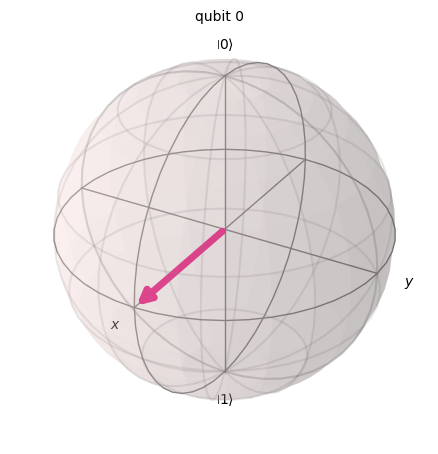

In [34]:
# STEP 8: Visualize Bloch sphere for a single qubit (|+> state)
print("\n🌀 Bloch Sphere of Qubit 0 (Superposition |+>):")
qc_single = QuantumCircuit(1)
qc_single.h(0)  # Hadamard on one qubit to create |+>
state = Statevector.from_instruction(qc_single)
plot_bloch_multivector(state.data)